# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [1]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("../data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [3]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()
clean = df.copy()

clean = clean.drop_duplicates()

clean['MSRP'] = clean['MSRP'].replace(2000, np.nan)

# 3. Typos / Outliers
clean.loc[clean['highway MPG'] == 354, 'highway MPG'] = np.nan

# 4. Missing values
clean['Engine Cylinders'] = clean['Engine Cylinders'].fillna(0)

# 5. Different units
clean['is_MPGe_unit'] = clean['Engine Fuel Type'] == 'electric'

# 7. Fill missing door values based on research
# Ferrari FF (2013, Coupe) -> 2 doors
clean.loc[(clean['Make'] == 'Ferrari') & (clean['Model'] == 'FF'), 'Number of Doors'] = 2.0
# Tesla Model S (2016, Sedan) -> 4 doors
clean.loc[(clean['Make'] == 'Tesla') & (clean['Model'] == 'Model S'), 'Number of Doors'] = 4.0


**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | Duplicates| Gemini|720 | Dropped | We already count it |
| 2 | Placeholder Values| Gemini| 747 (after dedup) | Replaced with NaN | so placeholders don't affect data |
| 3 | Typos | Gemini | 1 | Set to NaN | Typos will affect data|
| 4 | Missing Values| Gemini| Every EV or rotary engine | set to 0 | EVs don't have pistons and rotary engines are weird|
| 5 | Different Units| Gemini| Every EV | added EV Column| Its almost the same but could influence data when we look specifically at gas powered cars efficiency|
| 6 | Popularity is for makes| Gemini| Each Make | Ignored | Doesn't really matter |
| 7 | Missing door values| Gemini| 6 (1 Ferrari FF + 5 Tesla Model S) | Filled based on research | Easy to fix and might as well add them to the data |

In [4]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
# clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names

In [5]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11194, 16)
engine_fuel_type      3
engine_hp            69
highway_mpg           1
msrp                747
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

Mean price is 44788.66689001627 and Median price is 31870.0


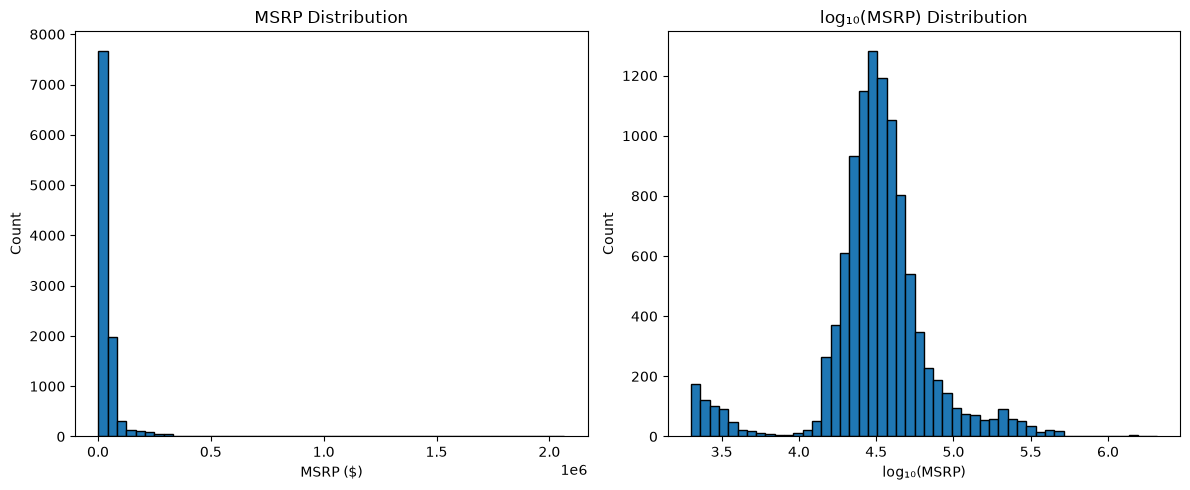

Share of cars above the mean: 22.82%


In [6]:
# a) mean and median
mean = clean["msrp"].mean()
median = clean["msrp"].median()
print("Mean price is {} and Median price is {}".format(mean, median))

# b) two histograms side by side (plt.subplots(1, 2))
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 

# Histogram 1: Full MSRP distribution
axes[0].hist(clean["msrp"].dropna(), bins=50, edgecolor="black")
axes[0].set_title("MSRP Distribution") 
axes[0].set_xlabel("MSRP ($)")
axes[0].set_ylabel("Count")

# Histogram 2: log10(MSRP) — should look roughly symmetric / bell-shaped
log_msrp = np.log10(clean["msrp"].dropna())
axes[1].hist(log_msrp, bins=50, edgecolor="black")
axes[1].set_title("log₁₀(MSRP) Distribution")
axes[1].set_xlabel("log₁₀(MSRP)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# c) share of cars above the mean
share_above_mean = (clean["msrp"] > mean).mean()
print(f"Share of cars above the mean: {share_above_mean:.2%}")


**Answer:**
Median price belongs on the homepage since its more representative of the actual expected average without due to the amount of outlier 

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [7]:
# get 2017 cars
cars_2017 = clean[clean['year'] == 2017]

# a) Mean and standard deviation of highway MPG by Vehicle Size
mpg_stats = cars_2017.groupby('vehicle_size')['highway_mpg'].agg(['mean', 'std'])  # renamed to avoid shadowing scipy.stats
print("--- 2017 Highway MPG Summary by Vehicle Size ---")
print(mpg_stats)

# b) Compute z-scores for each car within its class: z = (value - class mean) / class std
civic_mpg = 42
volvo_mpg = 34

compact_mean = mpg_stats.loc['Compact', 'mean']
compact_std = mpg_stats.loc['Compact', 'std']
z_civic = (civic_mpg - compact_mean) / compact_std

large_mean = mpg_stats.loc['Large', 'mean']
large_std = mpg_stats.loc['Large', 'std']
z_volvo = (volvo_mpg - large_mean) / large_std

print(f"\nHonda Civic (Compact) z-score: {z_civic:.2f}")
print(f"Volvo S90 (Large) z-score:     {z_volvo:.2f}")


--- 2017 Highway MPG Summary by Vehicle Size ---
                   mean        std
vehicle_size                      
Compact       31.994197  10.784983
Large         22.991453   3.491184
Midsize       29.410658   5.452292

Honda Civic (Compact) z-score: 0.93
Volvo S90 (Large) z-score:     3.15


**Answer:**
Volvo is much more impressive for their size since the average MPG for Large vechicles is much smaller and sits 3.5 SD away

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

a) 2017 Median MSRP: $36,737.50
b) 95% Bootstrap CI: [$35,940.00, $37,682.56]


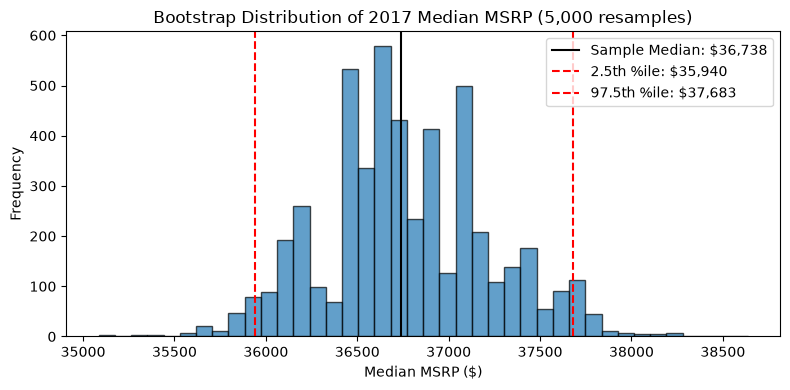


c) Volvo (n=23) Median MSRP: $46,350.00
Volvo 95% CI: [$41,750.00, $50,450.00]
All 2017 CI Width:   $1,742.56
Volvo CI Width:     $8,700.00


In [8]:
rng = np.random.default_rng(42)

def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    values = np.asarray(values)
    n = len(values)
    # Resample with replacement 5,000 times (matrix shape: n_boot x n)
    resamples = rng.choice(values, size=(n_boot, n), replace=True)
    return np.median(resamples, axis=1)

# --- a, b) All 2017 cars ---
cars_2017 = clean[clean['year'] == 2017]
prices_2017 = cars_2017['msrp'].dropna().values

# a) Compute sample median
sample_median = np.median(prices_2017)
print(f"a) 2017 Median MSRP: ${sample_median:,.2f}")

# b) Bootstrap 5,000 medians and calculate the 95% CI
medians_5000 = bootstrap_median(prices_2017, n_boot=5000)
ci_lower, ci_upper = np.percentile(medians_5000, [2.5, 97.5])

print(f"b) 95% Bootstrap CI: [${ci_lower:,.2f}, ${ci_upper:,.2f}]")

# Plot the distribution of medians
plt.figure(figsize=(8, 4))
plt.hist(medians_5000, bins=40, edgecolor='black', alpha=0.7)
plt.axvline(sample_median, color='black', linestyle='-', label=f'Sample Median: ${sample_median:,.0f}')
plt.axvline(ci_lower, color='red', linestyle='--', label=f'2.5th %ile: ${ci_lower:,.0f}')
plt.axvline(ci_upper, color='red', linestyle='--', label=f'97.5th %ile: ${ci_upper:,.0f}')
plt.title("Bootstrap Distribution of 2017 Median MSRP (5,000 resamples)")
plt.xlabel("Median MSRP ($)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# --- c) One make with < 50 cars in 2017 (e.g., Volvo with 23 cars) ---
make_name = 'Volvo'
make_prices = cars_2017[cars_2017['make'] == make_name]['msrp'].dropna().values

make_sample_median = np.median(make_prices)
make_medians_5000 = bootstrap_median(make_prices, n_boot=5000)
make_ci_lower, make_ci_upper = np.percentile(make_medians_5000, [2.5, 97.5])

print(f"\nc) {make_name} (n={len(make_prices)}) Median MSRP: ${make_sample_median:,.2f}")
print(f"{make_name} 95% CI: [${make_ci_lower:,.2f}, ${make_ci_upper:,.2f}]")
print(f"All 2017 CI Width:   ${ci_upper - ci_lower:,.2f}")
print(f"{make_name} CI Width:     ${make_ci_upper - make_ci_lower:,.2f}")


**Answer:**

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

Sample size (n): 509
Sample mean: 30.88 MPG


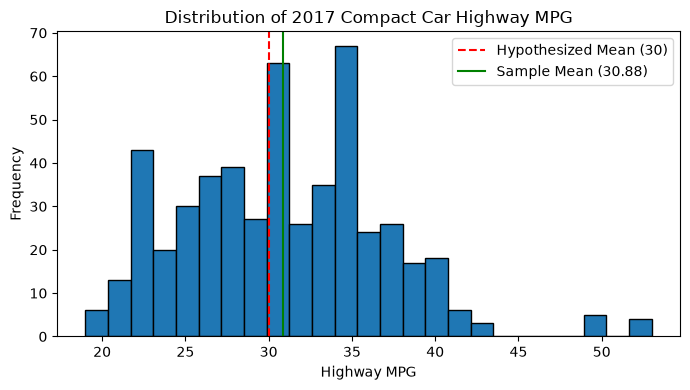

t-statistic: 3.2847
p-value:     0.000546

Rows per Make + Model summary:
count    85.000000
mean      5.988235
std       4.811925
min       1.000000
25%       2.000000
50%       6.000000
75%       8.000000
max      27.000000
dtype: float64

Aggregated sample size (unique models): 85
Aggregated mean:                        31.69 MPG
Aggregated t-statistic:                 2.5773
Aggregated p-value:                     0.005851


In [9]:
from scipy import stats
# --- a) 
# H0: mean <= 30
# HA: mean > 30
# One sided
# Marketing wants to specifically say its over 30


# get compact cars from 2017
compacts_2017 = clean[(clean['year'] == 2017) & (clean['vehicle_size'] == 'Compact')]

# exclude EVs
compacts_2017 = compacts_2017[compacts_2017['engine_fuel_type'] != 'electric']

#get rid of NaN
mpg_sample = compacts_2017['highway_mpg'].dropna()

# --- b) Sample size, mean, and histogram ---
n = len(mpg_sample)
mean_mpg = mpg_sample.mean()
print(f"Sample size (n): {n}")
print(f"Sample mean: {mean_mpg:.2f} MPG")

plt.figure(figsize=(7, 4))
plt.hist(mpg_sample, bins=25, edgecolor='black')
plt.axvline(30, color='red', linestyle='--', label='Hypothesized Mean (30)')
plt.axvline(mean_mpg, color='green', linestyle='-', label=f'Sample Mean ({mean_mpg:.2f})')
plt.title("Distribution of 2017 Compact Car Highway MPG")
plt.xlabel("Highway MPG")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# --- c) One-sample t-test vs 30 ---
t_stat, p_val = stats.ttest_1samp(mpg_sample, 30, alternative='greater')
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_val:.6f}")
# Because the p-value is far below our alpha = 0.05, we reject the null hypothesis. 
# There is statistically significant evidence to support marketing's claim that 2017 
# compact cars average more than 30 highway MPG.

# --- d) Independence check: Rows per make + model ---
counts_per_model = compacts_2017.groupby(['make', 'model']).size()
print("\nRows per Make + Model summary:")
print(counts_per_model.describe())

# Collapse to one observation per model (using the average MPG per model) and re-test
model_averages = compacts_2017.groupby(['make', 'model'])['highway_mpg'].mean()
t_stat_model, p_val_model = stats.ttest_1samp(model_averages, 30, alternative='greater')

print(f"\nAggregated sample size (unique models): {len(model_averages)}")
print(f"Aggregated mean:                        {model_averages.mean():.2f} MPG")
print(f"Aggregated t-statistic:                 {t_stat_model:.4f}")
print(f"Aggregated p-value:                     {p_val_model:.6f}")


**Answer:**

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [10]:
# Filter dataset for AUTOMATIC vs MANUAL only
clean_trans = clean[clean['transmission_type'].isin(['AUTOMATIC', 'MANUAL'])]

# a) Compare median MSRP by transmissions
median_msrp = clean_trans.groupby('transmission_type')['msrp'].median()
print("--- a) Overall Median MSRP ---")
print(median_msrp)

# b) Compare year by transmissions
print("\n--- b) Year Distribution by Transmission Type ---")
print(clean_trans.groupby('transmission_type')['year'].describe()[['mean', '25%', '50%', '75%']])

# I noticed there are less manuals than automatics per year, ie more automatic cars get made so they are chepaer cause they are old 

# c) Filter for 2015-2017 cars
recent = clean_trans[clean_trans['year'].between(2015, 2017)]

print("\n--- c) 2015-2017 Overall Median MSRP ---")
print(recent.groupby('transmission_type')['msrp'].median())

print("\n--- c) 2015-2017 Median MSRP by Vehicle Size ---")
size_medians = recent.groupby(['vehicle_size', 'transmission_type'])['msrp'].median().unstack()
print(size_medians)

# For 2015-2017 Compacts: Mann-Whitney U test
compacts_recent = recent[recent['vehicle_size'] == 'Compact']
auto_compacts = compacts_recent[compacts_recent['transmission_type'] == 'AUTOMATIC']['msrp'].dropna()
manual_compacts = compacts_recent[compacts_recent['transmission_type'] == 'MANUAL']['msrp'].dropna()

u_stat, p_val = stats.mannwhitneyu(auto_compacts, manual_compacts)
print(f"\n2015-2017 Compacts Auto Median:   ${auto_compacts.median():,.2f} (n={len(auto_compacts)})")
print(f"2015-2017 Compacts Manual Median: ${manual_compacts.median():,.2f} (n={len(manual_compacts)})")
print(f"Mann-Whitney U statistic: {u_stat:.1f}")
print(f"p-value:                  {p_val:.4f}")




--- a) Overall Median MSRP ---
transmission_type
AUTOMATIC    33620.0
MANUAL       21875.0
Name: msrp, dtype: float64

--- b) Year Distribution by Transmission Type ---
                          mean     25%     50%     75%
transmission_type                                     
AUTOMATIC          2011.843340  2009.0  2015.0  2016.0
MANUAL             2006.475503  1998.0  2008.0  2015.0

--- c) 2015-2017 Overall Median MSRP ---
transmission_type
AUTOMATIC    37065.0
MANUAL       26905.0
Name: msrp, dtype: float64

--- c) 2015-2017 Median MSRP by Vehicle Size ---
transmission_type  AUTOMATIC   MANUAL
vehicle_size                         
Compact              25995.0  25860.0
Large                44400.0  38395.0
Midsize              37980.0  26920.0

2015-2017 Compacts Auto Median:   $25,995.00 (n=1119)
2015-2017 Compacts Manual Median: $25,860.00 (n=589)
Mann-Whitney U statistic: 317261.0
p-value:                  0.2048


**Answer:**

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [11]:
rng = np.random.default_rng(42)

# Filter for trusted MPG rows (where the 354 outlier was removed)
# remove null and electric
trusted_cars = clean[clean['highway_mpg'].notnull()]
trusted_cars = trusted_cars[trusted_cars['engine_fuel_type'] != 'electric']

four_door = trusted_cars[trusted_cars['number_of_doors'] == 4]['highway_mpg'].values
two_door = trusted_cars[trusted_cars['number_of_doors'] == 2]['highway_mpg'].values

# --- a) Welch t-test (equal_var=False) ---
mean_4 = four_door.mean()
mean_2 = two_door.mean()
diff_in_means = mean_4 - mean_2

welch_res = stats.ttest_ind(four_door, two_door, equal_var=False)

print(f"a) 4-Door Mean: {mean_4:.2f} MPG | 2-Door Mean: {mean_2:.2f} MPG")
print(f"   Difference in Means (4-door - 2-door): {diff_in_means:.2f} MPG")
print(f"   Welch t-statistic: {welch_res.statistic:.4f}, p-value: {welch_res.pvalue:.2e}")

# --- b) Translate difference into dollars ---
miles_per_year = 12000
price_per_gallon = 3.50

cost_4 = (miles_per_year * price_per_gallon) / mean_4
cost_2 = (miles_per_year * price_per_gallon) / mean_2
savings = cost_2 - cost_4

print(f"\nb) Annual Fuel Cost (4-Door): ${cost_4:.2f}")
print(f"   Annual Fuel Cost (2-Door): ${cost_2:.2f}")
print(f"   Average Yearly Savings:    ${savings:.2f} (~${savings / 12:.2f}/month)")

# --- c) Simulation with 30 cars per group ---
n_sims, hits = 1000, 0
for _ in range(n_sims):
    sample_4 = rng.choice(four_door, size=30, replace=False)
    sample_2 = rng.choice(two_door, size=30, replace=False)
    
    res = stats.ttest_ind(sample_4, sample_2, equal_var=False)
    if res.pvalue < 0.05:
        hits += 1

fraction_significant = hits / n_sims
print(f"\nc) Fraction of simulations with p < 0.05: {fraction_significant:.3f} ({hits}/{n_sims})")



a) 4-Door Mean: 26.80 MPG | 2-Door Mean: 25.25 MPG
   Difference in Means (4-door - 2-door): 1.55 MPG
   Welch t-statistic: 11.9541, p-value: 1.59e-32

b) Annual Fuel Cost (4-Door): $1566.89
   Annual Fuel Cost (2-Door): $1663.15
   Average Yearly Savings:    $96.26 (~$8.02/month)

c) Fraction of simulations with p < 0.05: 0.158 (158/1000)


**Answer:**

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:**

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [12]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [13]:
# S2